In [1]:
suppressPackageStartupMessages({
    library(pheatmap)
    library(dplyr)
    library(ggplot2)
    library(tibble)
    library(RColorBrewer)
    library(grid)
    library(data.table)
    })

In [2]:
df <- fread('../../data/figure-inputs/scrna_objects/plasma_lit-state_scores_summary.csv')

# Define the signature mapping with symbols
signature_to_author_label <- list(
  'W1_unknown' = '● Unknown W1',
  'W10_DR16A' = '● DR16A',
  'W11_proliferation' = '● Proliferation',
  'W12_monocytic_contamination' = '● Monocyte',
  'W13_FOS' = '● FOS/AP-1',
  'W14_unknown' = '● Unknown W14',
  'W15_SMM8' = '● SMM8 State',
  'W16_normal_plasma' = '● Normal Plasma',
  'W17_MM5' = '● MM5 State (MYC)',
  'W18_JUN' = '● JUN',
  'W19_SMM7' = '● SMM7 State',
  'W2_MM1' = '● MM1 State',
  'W20_protein_synthesis' = '● Protein synthesis',
  'W21_ISFRA5' = '● ISFRA5',
  'W22_TMSB4X' = '● TMSB4X',
  'W23_MM3' = '● MM3 State',
  'W24_interferon_inducible' = '● ISG',
  'W25_UBC' = '● Ubiquitin C Up',
  'W26_unknown' = '● Unknown W26',
  'W27_nuclear_genes_opposite' = '● Nuclear Regulation',
  'W28_CXCR4' = '● CXCR4',
  'W3_t11_14' = '● t(11;14)',
  'W4_HLA_class_II' = '● HLA Class II',
  'W5_histones' = '● Histone',
  'W6_unknown' = '● Unknown W6',
  'W7_MM4' = '● MM4 State',
  'W8_t14_20' = '● t(14;20)',
  'W9_extracellular_signaling' = '● Extracellular Signal',
  'CTA_up' = '■ Testis Ag',
  'CD2_up' = '■ CCND1 - B cell high',
  'CD1_up' = '■ CCND1 - B cell low',
  'HY_up' = '■ Hyperdiploid',
  'MF_up' = '■ MAF/MAFB',
  'MS_up' = '■ MMSET/FGFR3',
  'M_up' = '■ Monocyte/Neutrophil',
  'NF_up' = '■ NFκB',
  'PR_up' = '■ Proliferation',
  'PRL3_up' = '■ PTP4A3/STAT3',
  'APOBEC_score_mean' = '▲ APOBEC Activity',
  'interferon_genes_up' = '▲ ISG',
  'Interferon_Alpha_Response' = '✖ ISG Alpha',
  'Interferon_Gamma_Response' = '✖ ISG Gamma'
)

# Get score columns
score_cols <- setdiff(names(df), c("barcodes", "plasma_labels_l3"))

# Calculate mean scores by plasma cell type
heatmap_data <- df %>%
  select(plasma_labels_l3, all_of(score_cols)) %>%
  group_by(plasma_labels_l3) %>%
  summarise_all(mean, na.rm = TRUE) %>%
  column_to_rownames("plasma_labels_l3")

# Rename columns using the signature mapping
col_names <- names(heatmap_data)
new_col_names <- sapply(col_names, function(x) {
  if (x %in% names(signature_to_author_label)) {
    return(signature_to_author_label[[x]])
  } else {
    return(x)
  }
})
names(heatmap_data) <- new_col_names

In [3]:
options(repr.plot.width = 14, repr.plot.height = 6)

# create pheatmap object without drawing
p <- pheatmap(
  heatmap_data,
  scale = "column",
  color = colorRampPalette(c("darkgreen", "white", "deeppink3"))(100),
  clustering_distance_rows = "euclidean",
  clustering_distance_cols = "euclidean",
  clustering_method = "complete",
  fontsize_row = 12,
  fontsize_col = 11,
  border_color = "black",
  main = "",
  angle_col = 45,
  silent = TRUE
)

# Save as PDF (vector) with cairo for better font handling
cairo_pdf(file = "../../data/figure-outputs/supplementary-1/sup_1g.pdf",
          width = 14, height = 6)
grid::grid.newpage()
grid::grid.draw(p$gtable)                          
grid::grid.text("● Boiarsky  ■ Broyl  ▲ Internal  ✖ MSigDB",
                x = 0.5, y = 0.98, gp = grid::gpar(fontsize = 12))
dev.off()

pdf 
  2

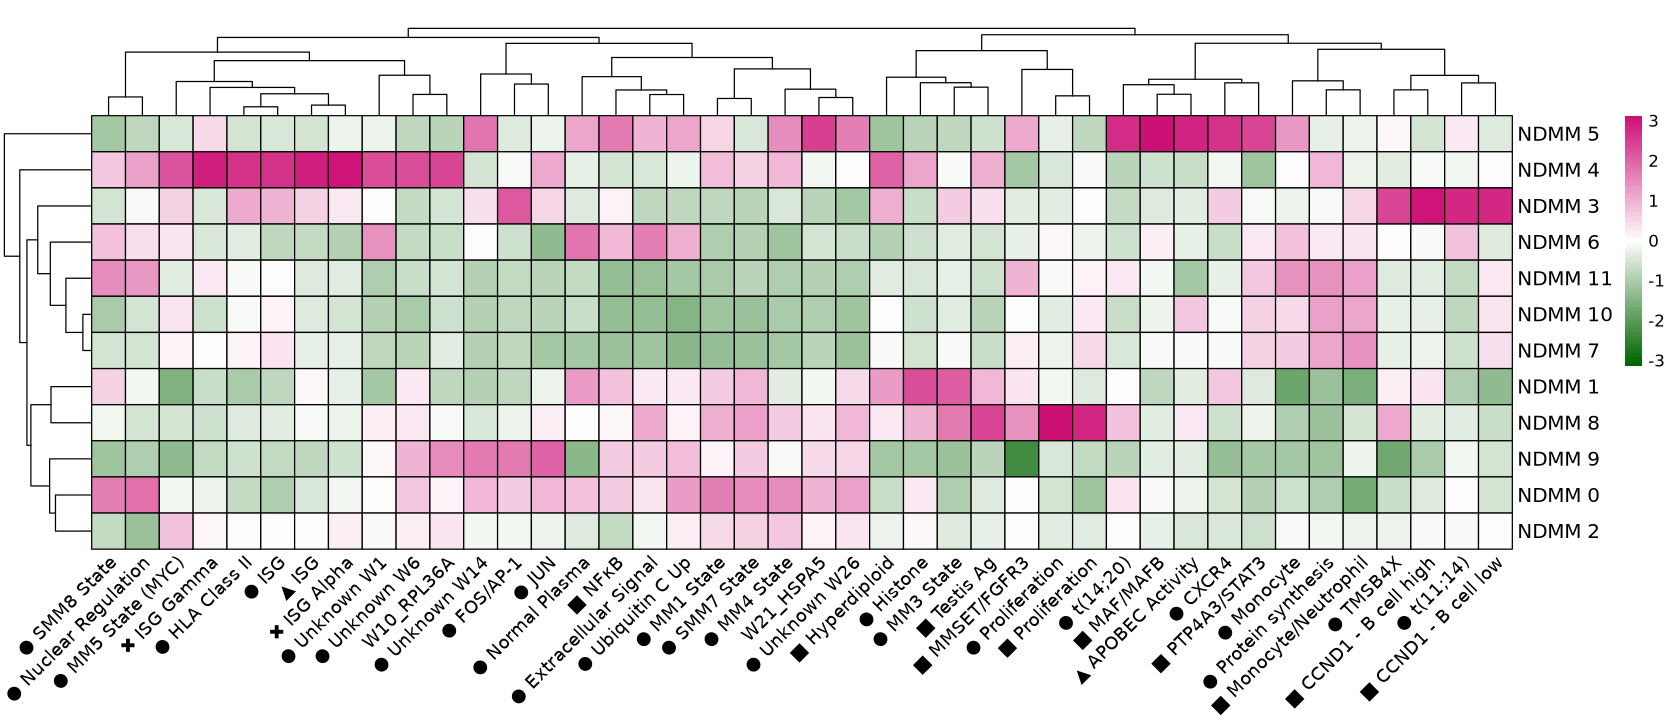

In [4]:
p

In [5]:
options(repr.plot.width = 14, repr.plot.height = 6)

# create pheatmap object without drawing
p <- pheatmap(
  heatmap_data,
  scale = "column",
  color = colorRampPalette(c("darkgreen", "white", "deeppink3"))(100),
  clustering_distance_rows = "euclidean",
  clustering_distance_cols = "euclidean",
  clustering_method = "complete",
  fontsize_row = 12,
  fontsize_col = 11,
  border_color = "black",
  main = "",
  angle_col = 45,
  silent = TRUE
)

# Save as PNG with high resolution
png(file = "../../data/figure-outputs/supplementary-1/sup_1g.png",
    width = 14, height = 6, units = "in", res = 300)
grid::grid.newpage()
grid::grid.draw(p$gtable)                          
grid::grid.text("● Boiarsky  ■ Broyl  ▲ Internal  ✖ MSigDB",
                x = 0.5, y = 0.98, gp = grid::gpar(fontsize = 12))
dev.off()

pdf 
  2